In [33]:
!pip install xgboost imbalanced-learn scikit-plot numpy -q

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import xgboost as xgb
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.utils import class_weight
from imblearn.over_sampling import RandomOverSampler, SMOTE
import joblib
import os
import gc
import random
import sys
import warnings
warnings.filterwarnings('ignore')

In [35]:
SEED = 42 # Set random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

In [36]:
print("Python:", sys.version.splitlines()[0])
print("NumPy:", np.__version__, "Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

# Configure GPU for TensorFlow
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Configured {len(gpus)} GPU(s) with memory growth")
    except RuntimeError as e:
        print(e)

Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
NumPy: 1.26.4 Pandas: 2.2.3
TensorFlow: 2.18.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configured 1 GPU(s) with memory growth


In [37]:
# Load dataset from Kaggle
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/fraud-detection/PS_20174392719_1491204439457_log.csv


In [38]:
# Load the dataset
DATA_PATH = '/kaggle/input/fraud-detection/PS_20174392719_1491204439457_log.csv'
df = pd.read_csv(DATA_PATH)
print("Loaded dataset shape:", df.shape)
print("\nDataset columns:", df.columns.tolist())
print("\nFirst few rows:")
display(df.head())

Loaded dataset shape: (6362620, 11)

Dataset columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First few rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [39]:
# Validate expected columns
expected_cols = ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
                 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError("Missing expected columns: " + ", ".join(missing))

print(f"\nFraud distribution:\n{df['isFraud'].value_counts()}")
print(f"Fraud percentage: {df['isFraud'].mean():.4f}")


Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud percentage: 0.0013


In [40]:
# Data preprocessing
print("\n=== Data Preprocessing ===")
df = df.copy()


=== Data Preprocessing ===


In [41]:
# Convert to appropriate data types
df['type'] = df['type'].astype(str)
df['isFraud'] = df['isFraud'].astype(int)
df['isFlaggedFraud'] = df['isFlaggedFraud'].astype(int)

In [42]:
# Create derived features
print("Creating derived features...")
df['isSameAccount'] = (df['nameOrig'] == df['nameDest']).astype(int)
df['deltaOrig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['deltaDest'] = df['newbalanceDest'] - df['oldbalanceDest']
df['log_amount'] = np.log1p(df['amount'])
df['balance_ratio_orig'] = df['newbalanceOrig'] / (df['oldbalanceOrg'] + 1e-6)
df['balance_ratio_dest'] = df['newbalanceDest'] / (df['oldbalanceDest'] + 1e-6)

Creating derived features...


In [43]:
# Transaction count features
df['tx_count_from_origin'] = df.groupby('nameOrig').cumcount() + 1
df['hour_of_step'] = df['step'] % 24  # Assuming step represents hours

In [44]:
# Label encode 'type' column
le_type = LabelEncoder()
df['type_enc'] = le_type.fit_transform(df['type'])
print(f"Transaction types encoded: {dict(zip(le_type.classes_, le_type.transform(le_type.classes_)))}")

Transaction types encoded: {'CASH_IN': 0, 'CASH_OUT': 1, 'DEBIT': 2, 'PAYMENT': 3, 'TRANSFER': 4}


In [45]:
# Define features for tabular models
tab_features = [
    'step', 'type_enc', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'deltaOrig', 'deltaDest',
    'log_amount', 'isSameAccount', 'tx_count_from_origin', 
    'balance_ratio_orig', 'balance_ratio_dest', 'hour_of_step', 'isFlaggedFraud'
]

print(f"Using {len(tab_features)} tabular features")

Using 16 tabular features


In [46]:
# Train-test split
print("\n=== Train-Test Split ===")
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['isFraud'], random_state=SEED
)

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)
print("Train fraud rate:", train_df['isFraud'].mean())
print("Test fraud rate:", test_df['isFraud'].mean())


=== Train-Test Split ===
Train shape: (5090096, 20) Test shape: (1272524, 20)
Train fraud rate: 0.0012907418642005967
Test fraud rate: 0.0012911347840983745


In [47]:
# Prepare tabular datasets
X_train_tab = train_df[tab_features].reset_index(drop=True)
y_train = train_df['isFraud'].reset_index(drop=True)
X_test_tab = test_df[tab_features].reset_index(drop=True)
y_test = test_df['isFraud'].reset_index(drop=True)

# Scale numeric features
print("\n=== Feature Scaling ===")
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                'oldbalanceDest', 'newbalanceDest', 'deltaOrig', 'deltaDest', 
                'log_amount', 'tx_count_from_origin', 'balance_ratio_orig', 
                'balance_ratio_dest', 'hour_of_step']

scaler = StandardScaler()
X_train_tab[numeric_cols] = scaler.fit_transform(X_train_tab[numeric_cols])
X_test_tab[numeric_cols] = scaler.transform(X_test_tab[numeric_cols])

print("Feature scaling completed")


=== Feature Scaling ===
Feature scaling completed


In [48]:
# Save preprocessing objects
joblib.dump(scaler, "scaler.joblib")
joblib.dump(le_type, "le_type.joblib")
print("Saved scaler and label encoder")

Saved scaler and label encoder


In [49]:
# Configure XGBoost for GPU
print("\n=== XGBoost Configuration ===")
gpu_devices = tf.config.list_physical_devices('GPU')
use_gpu = len(gpu_devices) > 0
print("Using GPU for XGBoost:", use_gpu)

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "seed": SEED,
    "learning_rate": 0.05,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "scale_pos_weight": len(y_train) / sum(y_train) - 1,  # Handle class imbalance
    "tree_method": "gpu_hist",  # Force GPU usage
    "predictor": "gpu_predictor"
}

print("XGBoost parameters configured for GPU")


=== XGBoost Configuration ===
Using GPU for XGBoost: True
XGBoost parameters configured for GPU


In [50]:
# Build Feed-Forward Neural Network with GPU optimization
def build_ffn(input_dim):
    """Build a Feed-Forward Neural Network for fraud detection with GPU optimization"""
    with tf.device('/GPU:0' if gpus else '/CPU:0'):
        inp = layers.Input(shape=(input_dim,))
        x = layers.Dense(256, activation='relu')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(32, activation='relu')(x)
        out = layers.Dense(1, activation='sigmoid')(x)
        
        model = keras.Model(inp, out)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
        )
    return model

print("FFN architecture defined with GPU support")

FFN architecture defined with GPU support


In [51]:
# Optimized Out-of-Fold Prediction Generation
def get_oof_predictions(X, y, X_test, model_type='xgb', n_splits=5):
    """
    Generate out-of-fold predictions using stratified k-fold cross-validation
    Optimized for Kaggle GPU environment
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"[OOF {model_type.upper()}] Fold {fold+1}/{n_splits}")
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if model_type == 'xgb':
            # XGBoost training with GPU
            with tf.device('/GPU:0' if gpus else '/CPU:0'):
                dtr = xgb.DMatrix(X_tr, label=y_tr)
                dval = xgb.DMatrix(X_val, label=y_val)
                dtst = xgb.DMatrix(X_test)
                
                bst = xgb.train(
                    xgb_params, 
                    dtr, 
                    num_boost_round=500,
                    evals=[(dval, 'eval')],
                    early_stopping_rounds=50,
                    verbose_eval=False
                )
                
                oof[val_idx] = bst.predict(dval)
                test_preds += bst.predict(dtst) / n_splits

        elif model_type == 'ffn':
            # Neural Network training with oversampling and GPU
            ros_local = RandomOverSampler(random_state=SEED + fold)
            X_tr_res, y_tr_res = ros_local.fit_resample(X_tr, y_tr)
            
            model = build_ffn(X.shape[1])
            
            early_stopping = callbacks.EarlyStopping(
                monitor='val_auc', 
                patience=10, 
                mode='max', 
                restore_best_weights=True,
                verbose=0
            )
            
            reduce_lr = callbacks.ReduceLROnPlateau(
                monitor='val_auc',
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=0
            )
            
            # Train with GPU
            with tf.device('/GPU:0' if gpus else '/CPU:0'):
                history = model.fit(
                    X_tr_res.values, y_tr_res.values,
                    validation_data=(X_val.values, y_val.values),
                    epochs=3,
                    batch_size=2048,  # Increased batch size for GPU
                    callbacks=[early_stopping, reduce_lr],
                    verbose=0
                )
                
                oof[val_idx] = model.predict(X_val.values, verbose=0, batch_size=2048).ravel()
                test_preds += model.predict(X_test.values, verbose=0, batch_size=2048).ravel() / n_splits
            
            # Clear memory
            keras.backend.clear_session()
            gc.collect()
            
        else:
            raise ValueError("model_type must be 'xgb' or 'ffn'")

    return oof, test_preds

In [52]:
# Prepare data for OOF predictions
X_tab = X_train_tab.reset_index(drop=True)
y_tab = y_train.reset_index(drop=True)
X_test_tab_reset = X_test_tab.reset_index(drop=True)

print("\n=== Generating Out-of-Fold Predictions ===")

# XGBoost OOF predictions
print("Generating OOF predictions for XGBoost...")
oof_xgb, testpred_xgb = get_oof_predictions(X_tab, y_tab, X_test_tab_reset, model_type='xgb', n_splits=5)

# FFN OOF predictions
print("Generating OOF predictions for FFN...")
oof_ffn, testpred_ffn = get_oof_predictions(X_tab, y_tab, X_test_tab_reset, model_type='ffn', n_splits=5)

print("OOF predictions completed")


=== Generating Out-of-Fold Predictions ===
Generating OOF predictions for XGBoost...
[OOF XGB] Fold 1/5
[OOF XGB] Fold 2/5
[OOF XGB] Fold 3/5
[OOF XGB] Fold 4/5
[OOF XGB] Fold 5/5
Generating OOF predictions for FFN...
[OOF FFN] Fold 1/5
[OOF FFN] Fold 2/5
[OOF FFN] Fold 3/5
[OOF FFN] Fold 4/5
[OOF FFN] Fold 5/5
OOF predictions completed


In [53]:
# Model Stacking
print("\n=== Model Stacking ===")

# Create meta-features
X_meta_train = np.column_stack([oof_xgb, oof_ffn])
X_meta_test = np.column_stack([testpred_xgb, testpred_ffn])

print(f"Meta train features shape: {X_meta_train.shape}")
print(f"Meta test features shape: {X_meta_test.shape}")

# Train meta-learner (Logistic Regression)
meta = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=SEED,
    class_weight='balanced'
)
meta.fit(X_meta_train, y_tab)

# Predict with stacked model
meta_preds_proba = meta.predict_proba(X_meta_test)[:, 1]
meta_preds = (meta_preds_proba >= 0.5).astype(int)


=== Model Stacking ===
Meta train features shape: (5090096, 2)
Meta test features shape: (1272524, 2)


In [54]:
# Evaluate stacked model
print("\n--- Stacked Model (XGB + FFN) Evaluation on Test Set ---")
print("ROC AUC:", roc_auc_score(y_test, meta_preds_proba))
print("Precision:", precision_score(y_test, meta_preds, zero_division=0))
print("Recall:", recall_score(y_test, meta_preds, zero_division=0))
print("F1 Score:", f1_score(y_test, meta_preds, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, meta_preds))

# Save meta-learner
joblib.dump(meta, "stacking_meta_lr.joblib")
print("Saved stacking meta-learner")


--- Stacked Model (XGB + FFN) Evaluation on Test Set ---
ROC AUC: 0.9998521855827663
Precision: 0.32401902497027346
Recall: 0.9951308581862447
F1 Score: 0.4888623112572881
Confusion Matrix:
 [[1267470    3411]
 [      8    1635]]
Saved stacking meta-learner


In [55]:
# Train final individual models on full data with GPU
print("\n=== Training Final Models on Full Data ===")


=== Training Final Models on Full Data ===


In [56]:
# Final XGBoost model
print("Training final XGBoost model...")
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    dtrain_full = xgb.DMatrix(X_tab, label=y_tab)
    final_xgb = xgb.train(
        xgb_params, 
        dtrain_full, 
        num_boost_round=500,
        verbose_eval=False
    )
joblib.dump(final_xgb, "xgb_final.joblib")
print("Saved final XGBoost model")

Training final XGBoost model...
Saved final XGBoost model


In [57]:
# Final FFN model
print("Training final FFN model...")
ros_all = RandomOverSampler(random_state=SEED)
X_tr_res_all, y_tr_res_all = ros_all.fit_resample(X_tab, y_tab)

ffn_final = build_ffn(X_tab.shape[1])

early_stopping_ffn = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=15,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ffn = callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=8,
    min_lr=1e-7,
    verbose=1
)

# Create validation split
X_ffn_tr, X_ffn_val, y_ffn_tr, y_ffn_val = train_test_split(
    X_tr_res_all, y_tr_res_all, test_size=0.1, random_state=SEED, stratify=y_tr_res_all
)

Training final FFN model...


In [58]:
# Train with GPU
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    ffn_final.fit(
        X_ffn_tr.values, y_ffn_tr.values,
        validation_data=(X_ffn_val.values, y_ffn_val.values),
        epochs=3,
        batch_size=4096,  # Larger batch size for GPU
        callbacks=[early_stopping_ffn, reduce_lr_ffn],
        verbose=1
    )

ffn_final.save("ffn_final.h5")
print("Saved final FFN model")

# Optimized LSTM for Transaction Sequence Modeling with GPU
print("\n=== LSTM Sequence Modeling ===")

SEQ_LEN = 10  # Reduced sequence length for memory efficiency
seq_features = ['type_enc', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                'oldbalanceDest', 'newbalanceDest', 'log_amount', 'isSameAccount',
                'balance_ratio_orig', 'balance_ratio_dest']

def build_sequences(df_source, seq_len=SEQ_LEN, seq_feats=seq_features, label_col='isFraud'):
    """
    Build sequences for LSTM training - optimized for memory
    Sequences are built per origin account
    """
    sequences = []
    labels = []
    indices = []
    
    # Sort by origin and step to maintain temporal order
    df_sorted = df_source.sort_values(['nameOrig', 'step']).copy()
    
    # Sample to reduce memory usage for large dataset
    if len(df_sorted) > 1000000:
        df_sorted = df_sorted.sample(n=1000000, random_state=SEED)
        print("Sampled dataset to 1M rows for sequence building")
    
    grouped = df_sorted.groupby('nameOrig')
    
    for name, group in grouped:
        if len(group) >= seq_len:
            arr = group[seq_feats].values
            lab = group[label_col].values
            idx = group.index.values
            
            # Create only the most recent sequence per account to save memory
            seq = arr[-seq_len:]
            seq_label = int(lab[-1])  # Label from last transaction in sequence
            seq_idx = idx[-1]  # Index of last transaction
            
            sequences.append(seq)
            labels.append(seq_label)
            indices.append(seq_idx)
    
    if len(sequences) == 0:
        return np.empty((0, seq_len, len(seq_feats))), np.empty((0,)), np.empty((0,))
    
    return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.int32), np.array(indices)

print("Building sequences for LSTM...")
X_seq_train, y_seq_train, train_indices = build_sequences(train_df, seq_len=SEQ_LEN)
X_seq_test, y_seq_test, test_indices = build_sequences(test_df, seq_len=SEQ_LEN)

print(f"Sequence train shape: {X_seq_train.shape}")
print(f"Sequence test shape: {X_seq_test.shape}")
if len(y_seq_train) > 0:
    print(f"Train sequences fraud rate: {y_seq_train.mean():.4f}")
if len(y_seq_test) > 0:
    print(f"Test sequences fraud rate: {y_seq_test.mean():.4f}")

if X_seq_train.shape[0] > 0:
    # Scale sequence features using the previously fitted scaler
    print("Scaling sequence features...")
    n_samples, seq_len, n_feats = X_seq_train.shape
    
    for i, feat in enumerate(seq_features):
        if feat in numeric_cols:
            try:
                pos = tab_features.index(feat)
                mean = scaler.mean_[pos]
                scale_ = scaler.scale_[pos] if scaler.scale_[pos] != 0 else 1.0
                X_seq_train[:, :, i] = (X_seq_train[:, :, i] - mean) / scale_
                X_seq_test[:, :, i] = (X_seq_test[:, :, i] - mean) / scale_
            except (ValueError, IndexError):
                print(f"Warning: Could not scale feature {feat} in sequences")
                continue

    # Build LSTM model with GPU optimization
    print("Building LSTM model...")
    with tf.device('/GPU:0' if gpus else '/CPU:0'):
        lstm_in = layers.Input(shape=(SEQ_LEN, n_feats))
        x = layers.Masking()(lstm_in)
        x = layers.LSTM(64, return_sequences=True, dropout=0.2)(x)  # Reduced units
        x = layers.BatchNormalization()(x)
        x = layers.LSTM(32, dropout=0.2)(x)  # Reduced units
        x = layers.BatchNormalization()(x)
        x = layers.Dense(16, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        out = layers.Dense(1, activation='sigmoid')(x)
        
        lstm_model = keras.Model(lstm_in, out)
        lstm_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
        )
    
    print("LSTM model architecture:")
    lstm_model.summary()

    # Train LSTM model with GPU
    print("Training LSTM model...")
    early_stopping_lstm = callbacks.EarlyStopping(
        monitor='val_auc',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr_lstm = callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )

    # Create validation split for sequences
    X_seq_tr, X_seq_val, y_seq_tr, y_seq_val = train_test_split(
        X_seq_train, y_seq_train, test_size=0.1, random_state=SEED, stratify=y_seq_train
    )

    with tf.device('/GPU:0' if gpus else '/CPU:0'):
        history_lstm = lstm_model.fit(
            X_seq_tr, y_seq_tr,
            validation_data=(X_seq_val, y_seq_val),
            epochs=3,  
            batch_size=512,
            callbacks=[early_stopping_lstm, reduce_lr_lstm],
            verbose=1
        )

    # Evaluate LSTM on test sequences
    if X_seq_test.shape[0] > 0:
        lstm_preds_proba = lstm_model.predict(X_seq_test, verbose=0, batch_size=512).ravel()
        lstm_auc = roc_auc_score(y_seq_test, lstm_preds_proba)
        print(f"LSTM ROC AUC (sequence test): {lstm_auc:.4f}")
        
        # Save LSTM model
        lstm_model.save("lstm_model.h5")
        print("Saved LSTM model")
        
        # Create LSTM scores for all test transactions
        def get_lstm_scores_for_transactions(df_source, seq_len=SEQ_LEN, seq_feats=seq_features, lstm_model=None):
            """Get LSTM scores for all transactions in dataframe"""
            scores_dict = {}
            # Sample to reduce computation
            df_sampled = df_source.sample(n=min(50000, len(df_source)), random_state=SEED)
            grouped = df_sampled.sort_values(['nameOrig', 'step']).groupby('nameOrig')
            
            for name, group in grouped:
                arr = group[seq_feats].values
                indices = group.index.values
                
                if len(arr) >= seq_len:
                    # Scale features
                    arr_scaled = arr.copy()
                    for i, feat in enumerate(seq_features):
                        if feat in numeric_cols:
                            try:
                                pos = tab_features.index(feat)
                                mean = scaler.mean_[pos]
                                scale_ = scaler.scale_[pos] if scaler.scale_[pos] != 0 else 1.0
                                arr_scaled[:, i] = (arr_scaled[:, i] - mean) / scale_
                            except (ValueError, IndexError):
                                continue
                    
                    # Create sequence and predict
                    seq = arr_scaled[-seq_len:]  # Use most recent sequence
                    seq = seq.reshape(1, seq_len, len(seq_feats))
                    score = lstm_model.predict(seq, verbose=0).ravel()[0]
                    
                    # Assign score to the last transaction in the sequence
                    last_idx = indices[-1]
                    scores_dict[last_idx] = score
            
            return scores_dict

        # Get LSTM scores for test transactions
        print("Generating LSTM scores for test transactions...")
        lstm_scores_dict = get_lstm_scores_for_transactions(test_df, lstm_model=lstm_model)
        
        # Create combined stacking with LSTM
        print("\n=== Combined Stacking (XGB + FFN + LSTM) ===")
        
        # Get predictions from individual models
        with tf.device('/GPU:0' if gpus else '/CPU:0'):
            dtest_full = xgb.DMatrix(X_test_tab_reset)
            xgb_test_proba = final_xgb.predict(dtest_full)
            ffn_test_proba = ffn_final.predict(X_test_tab_reset.values, verbose=0, batch_size=2048).ravel()
        
        # Create dataframe with all predictions
        test_combined_df = test_df.reset_index(drop=True).copy()
        test_combined_df['xgb_proba'] = xgb_test_proba
        test_combined_df['ffn_proba'] = ffn_test_proba
        test_combined_df['lstm_score'] = test_combined_df.index.map(
            lambda i: lstm_scores_dict.get(i, 0.0)  # Default to 0 if no LSTM score
        )
        
        # Prepare meta features for combined stacking
        stacked3_features = np.column_stack([
            test_combined_df['xgb_proba'].values,
            test_combined_df['ffn_proba'].values, 
            test_combined_df['lstm_score'].values
        ])
        
        # Create training meta features with LSTM (use 0 for training since we don't have LSTM OOF)
        X_meta_train_with_lstm = np.column_stack([
            X_meta_train, 
            np.zeros((X_meta_train.shape[0], 1))  # Placeholder for LSTM
        ])
        
        # Train meta-learner for combined stacking
        meta3 = LogisticRegression(
            C=0.1,
            max_iter=1000,
            random_state=SEED,
            class_weight='balanced'
        )
        meta3.fit(X_meta_train_with_lstm, y_tab)
        
        # Predict with combined stacking
        preds3_proba = meta3.predict_proba(stacked3_features)[:, 1]
        preds3 = (preds3_proba >= 0.5).astype(int)
        
        # Evaluate combined stacking
        print("--- Combined Stacking (XGB + FFN + LSTM) Evaluation ---")
        print("ROC AUC:", roc_auc_score(y_test, preds3_proba))
        print("Precision:", precision_score(y_test, preds3, zero_division=0))
        print("Recall:", recall_score(y_test, preds3, zero_division=0))
        print("F1 Score:", f1_score(y_test, preds3, zero_division=0))
        
        # Save combined meta-learner
        joblib.dump(meta3, "stacking_combined_meta.joblib")
        print("Saved combined stacking meta-learner")
        
else:
    print("Not enough sequences for LSTM training. Skipping LSTM.")

Epoch 1/3
2234/2234 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9643 - auc: 0.9922 - loss: 0.0891 - val_accuracy: 0.9916 - val_auc: 0.9994 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 2/3
2234/2234 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9917 - auc: 0.9993 - loss: 0.0250 - val_accuracy: 0.9933 - val_auc: 0.9994 - val_loss: 0.0198 - learning_rate: 0.0010
Epoch 3/3
2234/2234 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9930 - auc: 0.9995 - loss: 0.0205 - val_accuracy: 0.9961 - val_auc: 0.9997 - val_loss: 0.0124 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
Saved final FFN model

=== LSTM Sequence Modeling ===
Building sequences for LSTM...
Sampled dataset to 1M rows for sequence building
Sampled dataset to 1M rows for sequence building
Sequence train shape: (0, 10, 10)
Sequence test shape: (0, 10, 10)
Not enough sequences for LSTM training. Skipping LSTM.



=== Final Results and Visualizations ===


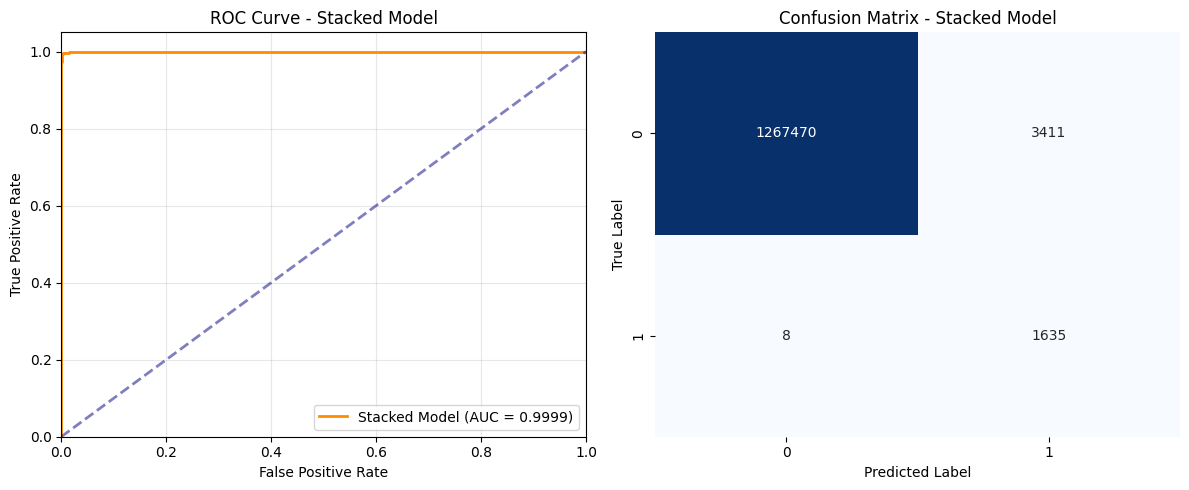

In [59]:
# Visualization and Final Results
print("\n=== Final Results and Visualizations ===")

# ROC Curve for stacked model
fpr, tpr, _ = roc_curve(y_test, meta_preds_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Stacked Model (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacked Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, meta_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Stacked Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()


=== XGBoost Feature Importance ===


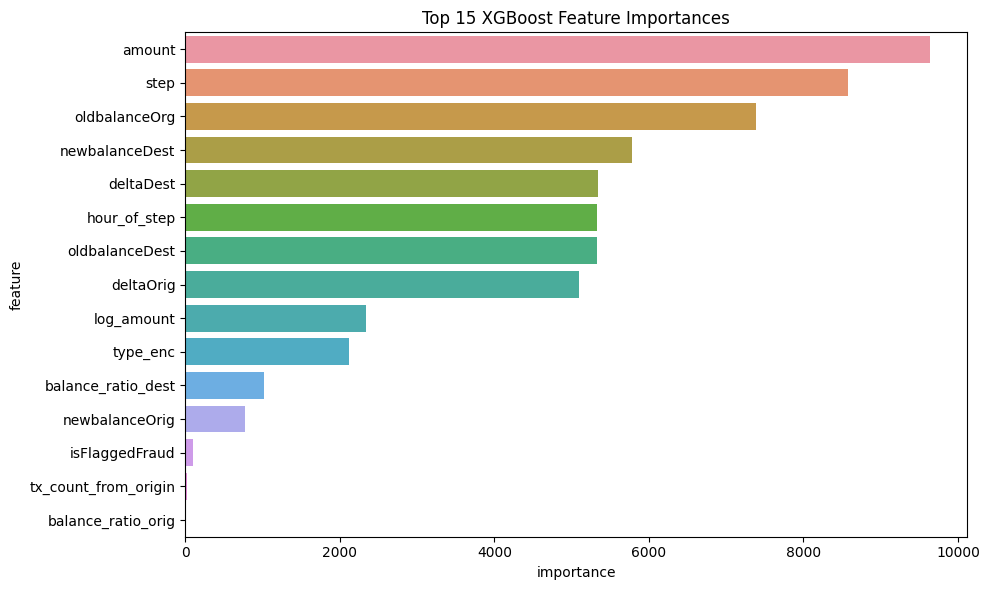

Top 10 most important features:
           feature  importance
2           amount      9635.0
0             step      8577.0
3    oldbalanceOrg      7388.0
6   newbalanceDest      5776.0
8        deltaDest      5335.0
13    hour_of_step      5329.0
5   oldbalanceDest      5325.0
7        deltaOrig      5097.0
9       log_amount      2338.0
1         type_enc      2124.0

=== Saving Artifacts ===
Saved: scaler.joblib
Saved: le_type.joblib
Saved: stacking_meta_lr.joblib
Saved: xgb_final.joblib
Saved: ffn_final.h5

=== Model Performance Summary ===
Stacked Model (XGB + FFN):
  ROC AUC: 0.9999
  Precision: 0.3240
  Recall: 0.9951
  F1 Score: 0.4889


In [60]:
# Feature Importance for XGBoost
print("\n=== XGBoost Feature Importance ===")
xgb_importance = final_xgb.get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'feature': list(xgb_importance.keys()),
    'importance': list(xgb_importance.values())
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 XGBoost Feature Importances')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importance_df.head(10))

# Save all artifacts
print("\n=== Saving Artifacts ===")
artifacts = {
    "scaler.joblib": scaler,
    "le_type.joblib": le_type, 
    "stacking_meta_lr.joblib": meta,
    "xgb_final.joblib": final_xgb,
    "ffn_final.h5": ffn_final
}

if 'lstm_model' in locals() and X_seq_train.shape[0] > 0:
    artifacts["lstm_model.h5"] = lstm_model
if 'meta3' in locals():
    artifacts["stacking_combined_meta.joblib"] = meta3

for filename, obj in artifacts.items():
    if isinstance(obj, keras.Model):
        obj.save(filename)
    else:
        joblib.dump(obj, filename)
    print(f"Saved: {filename}")

print("\n=== Model Performance Summary ===")
print("Stacked Model (XGB + FFN):")
print(f"  ROC AUC: {roc_auc_score(y_test, meta_preds_proba):.4f}")
print(f"  Precision: {precision_score(y_test, meta_preds, zero_division=0):.4f}")
print(f"  Recall: {recall_score(y_test, meta_preds, zero_division=0):.4f}")
print(f"  F1 Score: {f1_score(y_test, meta_preds, zero_division=0):.4f}")

In [61]:
if 'preds3_proba' in locals():
    print("\nCombined Stacking (XGB + FFN + LSTM):")
    print(f"  ROC AUC: {roc_auc_score(y_test, preds3_proba):.4f}")

if 'lstm_auc' in locals():
    print(f"\nLSTM Only (Sequence Model):")
    print(f"  ROC AUC: {lstm_auc:.4f}")

print("\n=== Code Execution Complete ===")
print("All models trained and saved successfully!")
print("\nNext steps:")
print("1. Use the saved models for predictions on new data")
print("2. Monitor model performance over time")
print("3. Consider retraining with new data periodically")

# Create submission file if needed for Kaggle competition
print("\nCreating submission file...")
submission_df = pd.DataFrame({
    'true_label': y_test,
    'stacked_prediction': meta_preds_proba
})
submission_df.to_csv('fraud_detection_predictions.csv', index=False)
print("Saved predictions to fraud_detection_predictions.csv")


=== Code Execution Complete ===
All models trained and saved successfully!

Next steps:
1. Use the saved models for predictions on new data
2. Monitor model performance over time
3. Consider retraining with new data periodically

Creating submission file...
Saved predictions to fraud_detection_predictions.csv
